## 授權與來源（License & Attribution）

本課程自編與改編內容：Copyright 2026 leonjyentub；授權：Apache License 2.0（`../LICENSE`）。
完整來源及授權資訊：`../SOURCES.md`、`../THIRD_PARTY_NOTICES.md`。

參考與改編來源：Aurélien Géron, `ageron/handson-mlp`（Apache-2.0），固定版本 `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`；`leonjyentub/MachineLearning2025` 為課程作者自有專案。
本教學檔案的變更與取捨：參考 handson-mlp Ch.1／Ch.4；另整合作者自己的 MachineLearning2025 迴歸、GD 與正則化示範。 將原範例重新編排，配合課堂增補解說、資料流程或縮小實驗；原作者不為本課程背書。

本授權只適用於本 Notebook 中權利人有權授權的程式與文字；第三方資料、圖片與其他權利依各原始條款。

# 01｜機器學習概觀

對應 `slides/01_機器學習概觀.md`。原分冊依教學順序合併，各節仍可獨立選講。

## 生活滿意度與線性模型

原始分冊：`01_從資料到線性模型.ipynb`。內容與已執行輸出完整併入本課同名 Notebook。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 用 GDP 預測生活滿意度
此為來源教材採用的歷史 OECD／World Bank 資料，不是最新國情或因果研究。

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
life = pd.read_csv(data_path('lifesat.csv'))
X = life[['GDP per capita (USD)']]
y = life['Life satisfaction']
linear = LinearRegression().fit(X,y)
knn = KNeighborsRegressor(n_neighbors=3).fit(X,y)
query = pd.DataFrame({'GDP per capita (USD)':[33442.8]})
print('Rows:', len(life), ' slope:', linear.coef_[0], ' intercept:', linear.intercept_)
pd.DataFrame({'model':['Linear regression','3-nearest neighbors'],
              'prediction':[linear.predict(query)[0],knn.predict(query)[0]]})

Rows: 27  slope: 6.778899694341222e-05  intercept: 3.7490494273769093


,model,prediction
0,Linear regression,6.016103
1,3-nearest neighbors,5.733333


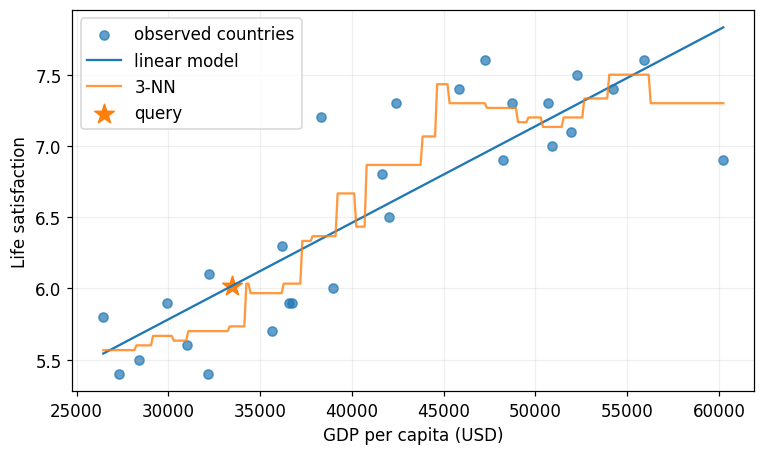

In [3]:
grid = pd.DataFrame({'GDP per capita (USD)':np.linspace(X.min().iloc[0], X.max().iloc[0],300)})
plt.scatter(X.iloc[:,0],y,label='observed countries',alpha=.7)
plt.plot(grid.iloc[:,0],linear.predict(grid),label='linear model')
plt.plot(grid.iloc[:,0],knn.predict(grid),label='3-NN',alpha=.8)
plt.scatter(query.iloc[:,0],linear.predict(query),marker='*',s=180,label='query')
plt.xlabel('GDP per capita (USD)'); plt.ylabel('Life satisfaction'); plt.legend()
savefig('01_lifesat_linear_knn')

**先預測再觀察：** k-NN 與線性模型在資料邊界外會怎樣？每人 GDP 增加一美元的斜率，能解讀成政策造成的效果嗎？

<details><summary>參考答案</summary>k-NN 使用附近已知樣本，邊界外通常維持邊界鄰居的平均；線性模型會沿直線外推。兩者都未保證域外準確。這是觀察相關，不能由斜率推論因果。</details>

## 2. 自行算出同一條迴歸線

為了讓學習率有可比較的尺度，先把 GDP 標準化。設計矩陣第一欄為 1；MSE 梯度為 $2X^T(Xw-y)/m$。這是批次更新，每一步使用全部訓練點。

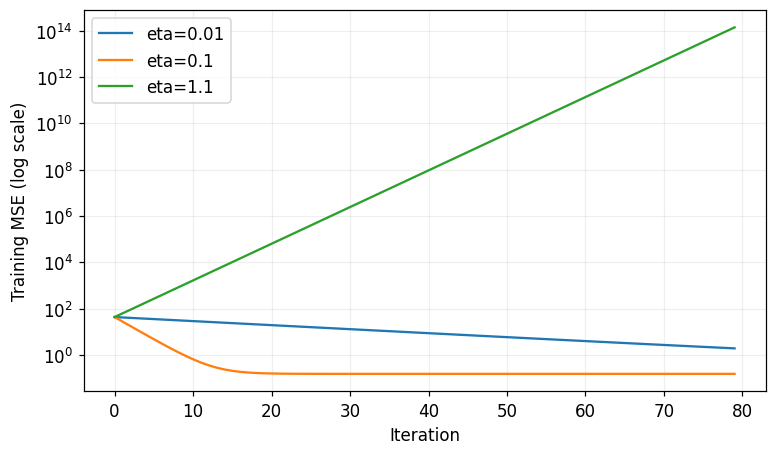

,learning_rate,last_logged_MSE
0,0.01,1.942593e+00
1,0.10,1.539460e-01
2,1.10,1.410723e+14


In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X)
Z = np.c_[np.ones(len(X)), scaler.transform(X)]
target = y.to_numpy()
def batch_gd(Z, target, eta, epochs=80):
    w = np.zeros(Z.shape[1])
    history = []
    for _ in range(epochs):
        error = Z @ w - target
        history.append(np.mean(error**2))
        w -= eta * (2/len(Z)) * Z.T @ error
    return w, np.array(history)
rows = []
for eta in [.01,.1,1.1]:
    w, loss = batch_gd(Z,target,eta)
    rows.append({'learning_rate':eta,'last_logged_MSE':loss[-1]})
    plt.semilogy(loss,label=f'eta={eta}')
plt.xlabel('Iteration'); plt.ylabel('Training MSE (log scale)'); plt.legend()
savefig('01_gradient_learning_rate')
pd.DataFrame(rows)

In [5]:
w, loss = batch_gd(Z,target,.1,epochs=200)
w_closed = np.linalg.lstsq(Z,target,rcond=None)[0]
assert np.allclose(w,w_closed,atol=1e-8)
assert np.allclose(Z@w,linear.predict(X),atol=1e-8)
report('linear', {'gdp_query':33442.8,'linear_prediction':linear.predict(query)[0],
                  'knn_prediction':knn.predict(query)[0], 'gd_weights_standardized':w.tolist()})
pd.DataFrame({'GD':w, 'least_squares':w_closed},index=['intercept','standardized GDP coefficient'])

,GD,least_squares
intercept,6.566667,6.566667
standardized GDP coefficient,0.640702,0.640702


## 練習：修改一項假設

將 k 改成 1 與 7，觀察曲線；先寫下你預期的平滑度。保留這組資料作示範，若要比較預測效果，另設驗證流程，不能只比較訓練線是否貼近散點。

**離堂檢核：** 係數是參數，k 與學習率是超參數。GD 求解與模型選擇是不同層次的工作。

## 泛化、正則化與早停

原始分冊：`02_驗證正則化與早停.ipynb`。內容與已執行輸出完整併入本課同名 Notebook。

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

In [7]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone
rng = np.random.default_rng(SEED)
X = rng.uniform(-5,5,size=(180,1))
y = .5*X[:,0]**2-X[:,0]+2+rng.normal(0,3,len(X))
X_dev,X_test,y_dev,y_test = train_test_split(X,y,test_size=.2,random_state=SEED)
X_train,X_val,y_train,y_val = train_test_split(X_dev,y_dev,test_size=.25,random_state=SEED)
folds = list(KFold(5,shuffle=True,random_state=SEED).split(X_train))
print('train / validation / test:',len(X_train),len(X_val),len(X_test))
def poly_model(degree, estimator):
    return make_pipeline(PolynomialFeatures(degree,include_bias=False),StandardScaler(),estimator)

train / validation / test: 108 36 36


## 1. 同一批資料，改變複雜度
先畫訓練點與已知生成函數，再比較 training RMSE 和 5-fold CV RMSE。CV 每折重新 fit 多項式後的縮放器。

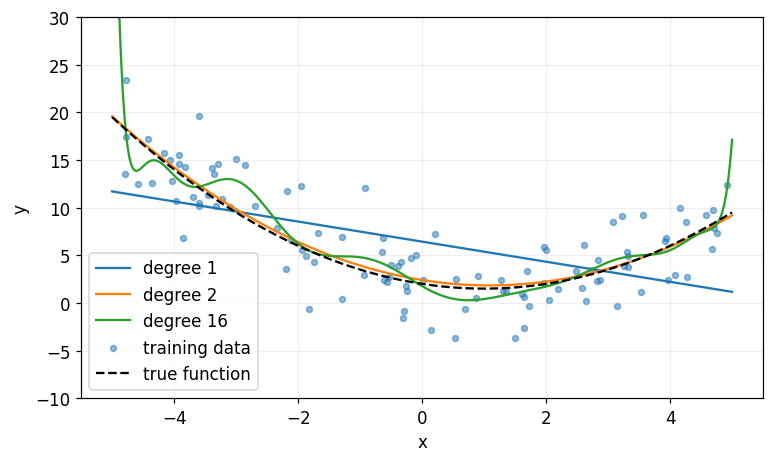

,degree,train_RMSE,CV_RMSE_mean,CV_RMSE_sd
0,1,4.577528,4.643568,0.964016
1,2,2.998631,3.161724,0.244873
2,16,2.809885,4.167049,1.678580


In [8]:
grid = np.linspace(-5,5,400).reshape(-1,1)
rows=[]
for degree in [1,2,16]:
    model = poly_model(degree,LinearRegression()).fit(X_train,y_train)
    cv = -cross_val_score(model,X_train,y_train,cv=folds,scoring='neg_root_mean_squared_error')
    rows.append({'degree':degree,'train_RMSE':root_mean_squared_error(y_train,model.predict(X_train)),
                 'CV_RMSE_mean':cv.mean(),'CV_RMSE_sd':cv.std(ddof=1)})
    plt.plot(grid,model.predict(grid),label=f'degree {degree}')
plt.scatter(X_train,y_train,s=15,alpha=.5,label='training data')
plt.plot(grid,.5*grid**2-grid+2,'k--',label='true function')
plt.ylim(-10,30);plt.xlabel('x');plt.ylabel('y');plt.legend()
savefig('02_model_complexity')
pd.DataFrame(rows)

## 2. 固定 degree，改變正則化
`PolynomialFeatures → StandardScaler → estimator`。L1 可產生零係數，L2 通常連續縮小係數；不同懲罰的 alpha 不代表相同強度。以下依 CV RMSE 選候選，驗證集留給下一段早停。

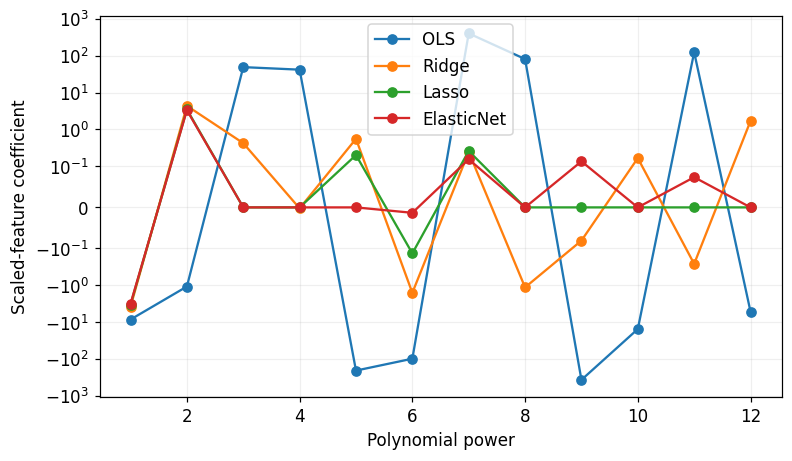

,model,CV_RMSE,coefficient_L2_norm,near_zero_coefficients
1,Ridge,3.182865,6.409720,0
3,ElasticNet,3.215419,4.604230,6
2,Lasso,3.215893,4.840578,7
0,OLS,3.448076,610.331749,0


In [9]:
candidates = {'OLS':LinearRegression(), 'Ridge':Ridge(alpha=1),
              'Lasso':Lasso(alpha=.05,max_iter=100000,tol=1e-4),
              'ElasticNet':ElasticNet(alpha=.05,l1_ratio=.5,max_iter=100000,tol=1e-4)}
reg_rows=[]; fitted={}
for name,estimator in candidates.items():
    pipe=poly_model(12,estimator).fit(X_train,y_train)
    fitted[name]=pipe
    cv=-cross_val_score(pipe,X_train,y_train,cv=folds,scoring='neg_root_mean_squared_error')
    coef=pipe[-1].coef_
    reg_rows.append({'model':name,'CV_RMSE':cv.mean(),'coefficient_L2_norm':np.linalg.norm(coef),
                     'near_zero_coefficients':int(np.sum(np.abs(coef)<1e-8))})
    plt.plot(np.arange(1,13),coef,marker='o',label=name)
plt.yscale('symlog',linthresh=.1);plt.xlabel('Polynomial power');plt.ylabel('Scaled-feature coefficient');plt.legend()
savefig('02_regularization_coefficients')
reg_table=pd.DataFrame(reg_rows).sort_values('CV_RMSE')
reg_table

## 補充：正則化快算

對應投影片「快算：不同係數如何受到懲罰」。兩個模型的 MSE 都是 2、特徵同尺度，比較係數向量 $(3,0)$ 與 $(1.5,1.5)$ 在 $\lambda=1$、$J=\mathrm{MSE}+\lambda\Omega$ 下的懲罰與總目標。這只是兩組固定係數的比較，不足以證明 L1 一定得到稀疏解；稀疏性的幾何直覺見投影片。

In [10]:
coef_sets={'A (3, 0)':np.array([3.,0.]),'B (1.5, 1.5)':np.array([1.5,1.5])}
penalty=pd.DataFrame({name:{'L1':np.abs(c).sum(),'L2':np.sum(c**2)} for name,c in coef_sets.items()}).T
penalty['J_with_L1']=2+penalty.L1
penalty['J_with_L2']=2+penalty.L2
assert penalty.L1.tolist()==[3.,3.] and penalty.L2.tolist()==[9.,4.5]
assert penalty.J_with_L2.tolist()==[11.,6.5]
penalty

,L1,L2,J_with_L1,J_with_L2
"A (3, 0)",3.0,9.0,5.0,11.0
"B (1.5, 1.5)",3.0,4.5,5.0,6.5


## 3. 早停：每個 epoch 看 validation，保存並恢復最佳狀態

這裡使用整批資料的一次 `partial_fit` 作為一個 epoch；SGD 在其中逐筆更新。最大 1,200 epochs、patience 80、以驗證 RMSE 嚴格改善為準，規則在看曲線前固定。不同資料不一定出現明顯 U 形；沒有觸發早停也應照實報告。

原範例把 `X_test` 用於選 epoch；本版改用 validation，真正 test 最後才讀取評估。

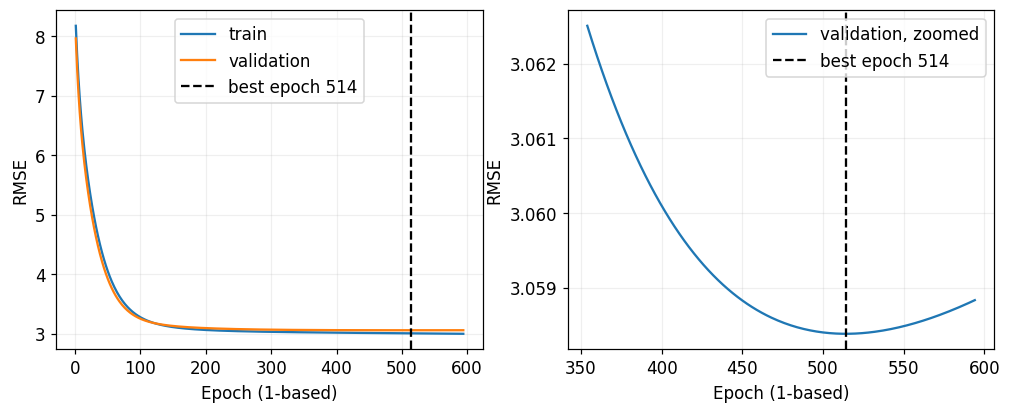

Executed epochs: 594 best epoch (1-based): 514 patience triggered: True


In [11]:
import copy
preprocess=make_pipeline(PolynomialFeatures(12,include_bias=False),StandardScaler())
Z_train=preprocess.fit_transform(X_train)
Z_val=preprocess.transform(X_val)
sgd=SGDRegressor(penalty=None,learning_rate='constant',eta0=.0002,random_state=SEED)
best_loss=np.inf; best_epoch=-1; best_model=None; patience=80
curve=[]
for epoch in range(1200):
    sgd.partial_fit(Z_train,y_train)
    tr=root_mean_squared_error(y_train,sgd.predict(Z_train))
    va=root_mean_squared_error(y_val,sgd.predict(Z_val))
    curve.append((tr,va))
    if va < best_loss:
        best_loss=va;best_epoch=epoch;best_model=copy.deepcopy(sgd)
    if epoch-best_epoch >= patience:
        break
curve=np.asarray(curve)
assert np.isclose(root_mean_squared_error(y_val,best_model.predict(Z_val)),curve[:,1].min())
epochs=np.arange(1,len(curve)+1)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(epochs,curve[:,0],label='train');axes[0].plot(epochs,curve[:,1],label='validation')
zoom_start=max(0,best_epoch-160)
axes[1].plot(epochs[zoom_start:],curve[zoom_start:,1],label='validation, zoomed')
for ax in axes:
    ax.axvline(best_epoch+1,color='k',ls='--',label=f'best epoch {best_epoch+1}')
    ax.set(xlabel='Epoch (1-based)',ylabel='RMSE');ax.legend()
savefig('02_early_stopping')
print('Executed epochs:',len(curve),'best epoch (1-based):',best_epoch+1,
      'patience triggered:',epoch-best_epoch>=patience)

## 4. 最後一次開啟 test
兩條事先指定的流程：CV 選出的正則化候選、validation 選出的早停 checkpoint。測試結果只報告，不反過來改 alpha 或 epoch。這是小型教學比較，不能推論某方法普遍勝出。

In [12]:
chosen_name=reg_table.iloc[0]['model']
chosen=clone(fitted[chosen_name]).fit(X_dev,y_dev)
test_results={'CV_selected_model':chosen_name,
              'CV_selected_test_RMSE':root_mean_squared_error(y_test,chosen.predict(X_test)),
              'early_stopped_test_RMSE':root_mean_squared_error(y_test,best_model.predict(preprocess.transform(X_test))),
              'best_epoch':best_epoch+1,'epochs_executed':len(curve)}
report('regularization',test_results)
pd.Series(test_results)

CV_selected_model             Ridge
CV_selected_test_RMSE       2.76219
early_stopped_test_RMSE    2.764103
best_epoch                      514
epochs_executed                 594
dtype: object

## 5. 選做：把偏差與變異數數據化

只有合成資料才知道真函數。重複抽取 80 組訓練資料；在同一網格上分解平方誤差：$E[(\hat f-f)^2]=bias^2+variance$。下圖不包含不可約觀測雜訊；若預測新帶雜訊 y，需再加噪音變異數 9。有限網格與有限重複次數僅為估計。

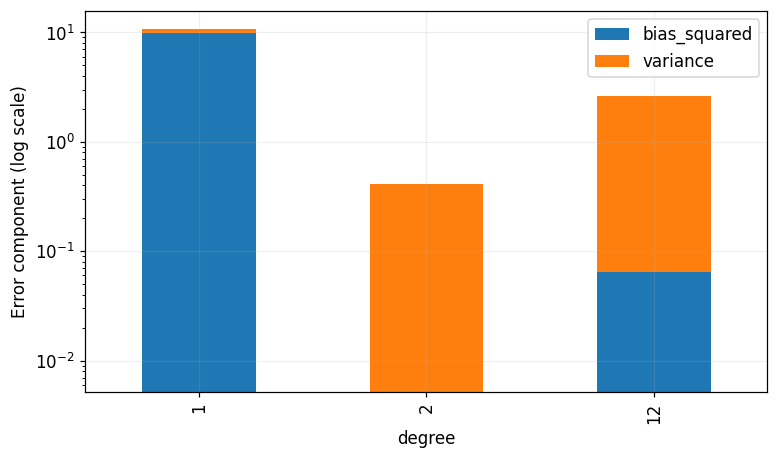

,bias_squared,variance,function_MSE
degree,,,
1,9.845957,0.878896,10.724854
2,0.005180,0.407653,0.412833
12,0.064564,2.546879,2.611442


In [13]:
rng=np.random.default_rng(SEED)
xgrid=np.linspace(-4.5,4.5,100).reshape(-1,1)
ftrue=.5*xgrid[:,0]**2-xgrid[:,0]+2
bv=[]
for degree in [1,2,12]:
    predictions=[]
    for _ in range(80):
        xs=rng.uniform(-5,5,(60,1));ys=.5*xs[:,0]**2-xs[:,0]+2+rng.normal(0,3,60)
        predictions.append(poly_model(degree,LinearRegression()).fit(xs,ys).predict(xgrid))
    predictions=np.array(predictions)
    bias2=np.mean((predictions.mean(axis=0)-ftrue)**2)
    variance=np.mean(predictions.var(axis=0))
    error=np.mean((predictions-ftrue)**2)
    assert np.isclose(error,bias2+variance)
    bv.append({'degree':degree,'bias_squared':bias2,'variance':variance,'function_MSE':error})
bv=pd.DataFrame(bv).set_index('degree')
bv[['bias_squared','variance']].plot.bar(stacked=True,logy=True)
plt.ylabel('Error component (log scale)');savefig('02_bias_variance')
bv

## 練習與參考答案

- 將正則化強度設成 0.001／1／100，在同一 CV folds 比較；執行新的探索後，原 test 已看過，不能再稱為全新獨立驗證。
- 若最後一輪模型與最佳模型不同，部署哪一個？**驗證集選中的 checkpoint。**
- 增加模型複雜度是否一定改善？**訓練誤差與泛化誤差的變化不相同。**

## 評估設計與常見陷阱

原始分冊：`08_研究延伸與常見陷阱.ipynb`。內容與已執行輸出完整併入本課同名 Notebook。

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 沒有單一模型在所有問題都最好：兩個反例

讓線性模型與 k-NN 在「直線」與「波浪」函數上比較。這只能呈現歸納偏好如何配合問題；有限實驗不是 No Free Lunch 定理的證明，也不表示在特定問題族中無法找到表現良好的方法。

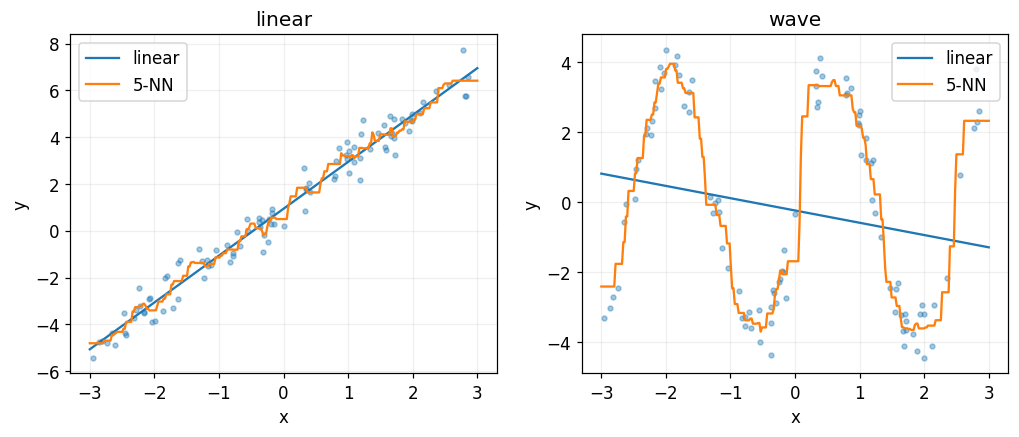

model,5-NN,linear
task,,
linear,0.562074,0.495331
wave,0.830120,2.845412


In [15]:
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, HuberRegressor
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit, cross_val_score
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
rng=np.random.default_rng(SEED)
xtrain=rng.uniform(-3,3,(100,1));xtest=rng.uniform(-3,3,(500,1));xline=np.linspace(-3,3,300)[:,None]
functions={'linear':lambda x:2*x[:,0]+1,'wave':lambda x:4*np.sin(2.5*x[:,0])}
rows=[];fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,(name,f) in zip(axes,functions.items()):
    yt=f(xtrain)+rng.normal(0,.5,len(xtrain));yv=f(xtest)+rng.normal(0,.5,len(xtest))
    ax.scatter(xtrain,yt,s=10,alpha=.4)
    for model_name,estimator in [('linear',LinearRegression()),('5-NN',KNeighborsRegressor(5))]:
        estimator.fit(xtrain,yt)
        rows.append({'task':name,'model':model_name,'test_RMSE':root_mean_squared_error(yv,estimator.predict(xtest))})
        ax.plot(xline,estimator.predict(xline),label=model_name)
    ax.set(xlabel='x',ylabel='y',title=name);ax.legend()
savefig('08_inductive_bias')
pd.DataFrame(rows).pivot(index='task',columns='model',values='test_RMSE')

## 2. 故意犯錯：在 CV 外選特徵

純亂數的 X 與 y 沒有訊號。若先用所有標籤挑高相關特徵，再做 CV，驗證標籤已滲入特徵選擇。以下 `leaky` 是明示反例，不能移到正式流程；`proper` 在每折內選特徵。重複 8 組合成資料，報告每次結果，而不挑最誇張的一次。

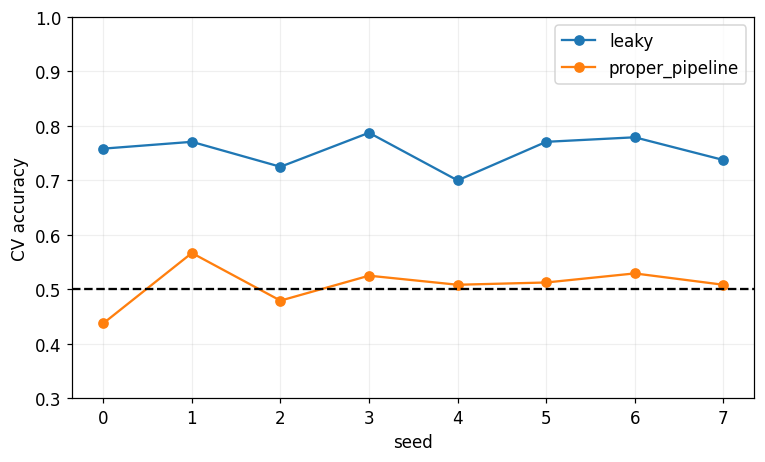

,leaky,proper_pipeline
seed,,
0,0.758333,0.437500
1,0.770833,0.566667
2,0.725000,0.479167
3,0.787500,0.525000
4,0.700000,0.508333
5,0.770833,0.512500
6,0.779167,0.529167
7,0.737500,0.508333


In [16]:
from sklearn.feature_selection import SelectKBest,f_classif
leak_rows=[]
for seed in range(8):
    rng=np.random.default_rng(seed)
    X=rng.normal(size=(240,2000));y=rng.integers(0,2,240)
    folds=list(StratifiedKFold(4,shuffle=True,random_state=SEED).split(X,y))
    estimator=LogisticRegression(max_iter=1000)
    X_leaky=SelectKBest(f_classif,k=20).fit_transform(X,y)  # 故意錯誤示範
    leaky=cross_val_score(estimator,X_leaky,y,cv=folds).mean()
    proper=cross_val_score(make_pipeline(SelectKBest(f_classif,k=20),estimator),X,y,cv=folds).mean()
    leak_rows.append({'seed':seed,'leaky':leaky,'proper_pipeline':proper})
leak_table=pd.DataFrame(leak_rows).set_index('seed')
leak_table.plot(marker='o');plt.axhline(.5,color='k',ls='--');plt.ylabel('CV accuracy');plt.ylim(.3,1)
savefig('08_feature_selection_leakage')
leak_table

## 3. 同一個人的資料分在兩邊：群組洩漏

合成 60 個群組，每組 8 筆。特徵含群組身分，標籤只由群組亂數決定。隨機拆列可記住同一組；GroupKFold 才問「沒見過的群組」能否預測。這對同一學生多次作答、同一病人多張影像、同一裝置多筆紀錄都提供驗證設計的提醒。

In [17]:
rng=np.random.default_rng(SEED)
groups=np.repeat(np.arange(60),8)
group_y=rng.integers(0,2,60);y=group_y[groups]
X=np.eye(60)[groups]+rng.normal(0,.005,(len(groups),60))
random_folds=list(StratifiedKFold(5,shuffle=True,random_state=SEED).split(X,y))
group_folds=list(GroupKFold(5).split(X,y,groups))
for tr,va in group_folds:
    assert not set(groups[tr])&set(groups[va])
knn=KNeighborsClassifier(3)
group_results={'random_row_CV':cross_val_score(knn,X,y,cv=random_folds).mean(),
               'unseen_group_CV':cross_val_score(knn,X,y,cv=group_folds).mean()}
pd.Series(group_results)

random_row_CV      1.000000
unseen_group_CV    0.477083
dtype: float64

## 4. 時間資料：讓訓練時間早於驗證時間

圖示比較 shuffled KFold 與 TimeSeriesSplit。後者逐步擴大過去資料，並在訓練與驗證間留 gap=3；gap 的實際長度應配合特徵視窗、標籤延遲與資料相依。這裡只驗證切分語意，沒有把一種切分的分數當成另一種任務的優劣。

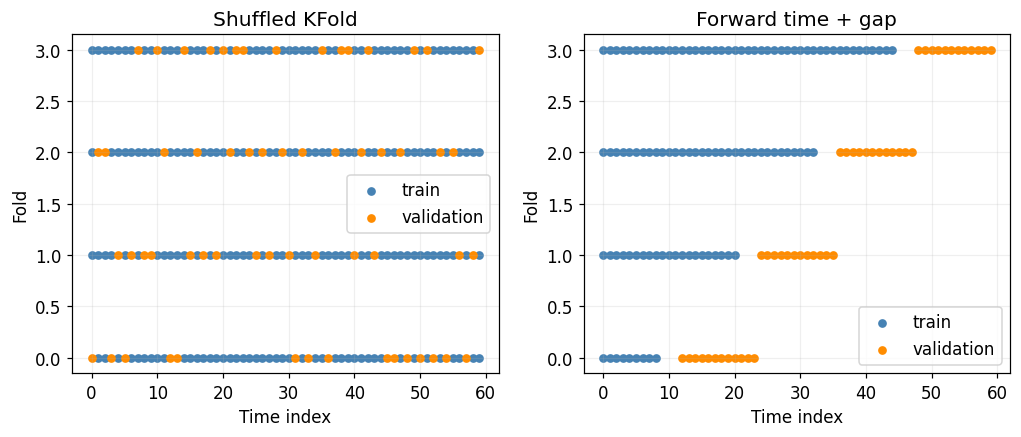

In [18]:
timeline=np.arange(60)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,(name,splitter) in zip(axes,[('Shuffled KFold',KFold(4,shuffle=True,random_state=SEED)),
                                  ('Forward time + gap',TimeSeriesSplit(4,gap=3))]):
    for fold,(tr,va) in enumerate(splitter.split(timeline)):
        if isinstance(splitter,TimeSeriesSplit):assert tr.max()<va.min()-3
        ax.scatter(tr,np.repeat(fold,len(tr)),c='steelblue',s=22,label='train' if fold==0 else None)
        ax.scatter(va,np.repeat(fold,len(va)),c='darkorange',s=22,label='validation' if fold==0 else None)
    ax.set(xlabel='Time index',ylabel='Fold',title=name);ax.legend()
savefig('08_group_time_splits')

## 5. Train-dev 幫忙區分過擬合與來源差異

在這個已知生成機制的例子裡，source 與 target 都遵循 $y=x^2+noise$，但 X 的分布改變（covariate shift）。source 的保留集稱為 train-dev；target-dev 模擬使用環境。只用 source training fit 一次線性模型，再觀察三種誤差。

target-dev 誤差變大是分布差異與線性模型假設共同作用。真實資料中，單靠這三個誤差不能唯一診斷漂移原因；還要檢查來源、標籤品質與抽樣方式。

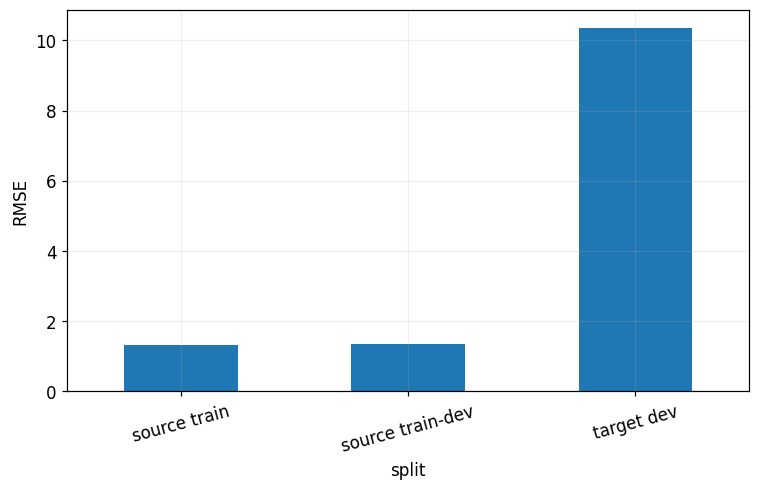

,split,RMSE,x_mean
0,source train,1.311260,-0.041079
1,source train-dev,1.358787,0.102490
2,target dev,10.337109,2.938995


In [19]:
rng=np.random.default_rng(SEED)
source_x=rng.normal(0,1,(400,1));source_y=source_x[:,0]**2+rng.normal(0,.4,400)
target_x=rng.normal(3,1,(160,1));target_y=target_x[:,0]**2+rng.normal(0,.4,160)
model=LinearRegression().fit(source_x[:300],source_y[:300])
mismatch=[]
for name,Xpart,ypart in [('source train',source_x[:300],source_y[:300]),
                         ('source train-dev',source_x[300:],source_y[300:]),
                         ('target dev',target_x,target_y)]:
    mismatch.append({'split':name,'RMSE':root_mean_squared_error(ypart,model.predict(Xpart)),'x_mean':Xpart.mean()})
pd.DataFrame(mismatch).set_index('split')['RMSE'].plot.bar();plt.xticks(rotation=15);plt.ylabel('RMSE')
savefig('08_data_mismatch')
pd.DataFrame(mismatch)

## 6. Concept drift：先預測，等標籤到來，再更新

X 的分布保持相同；第 2,000 筆起，真實關係從 $y=2x+noise$ 改成 $y=-2x+noise$，所以是概念漂移。凍結模型與增量模型都先在最初 500 筆訓練；逐批 100 筆 **先評估，再 partial_fit**。此例假設每批結束即取得真實標籤，不能直接套用到標籤延遲數月的場景。

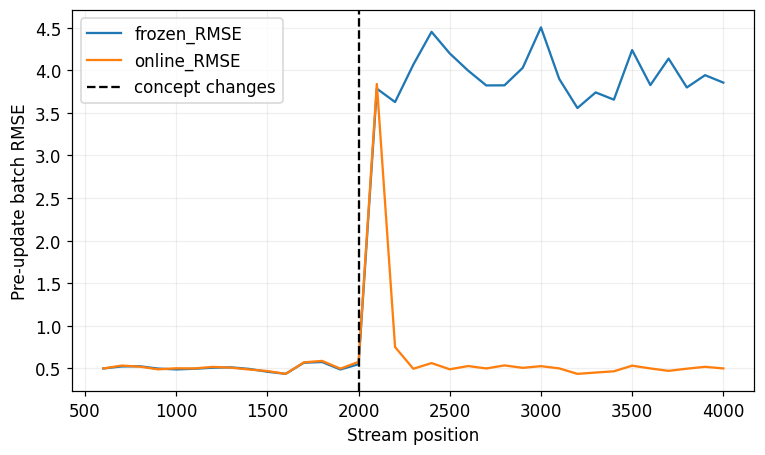

,frozen_RMSE,online_RMSE
batch_end,,
3600,3.825737,0.500352
3700,4.136937,0.471790
3800,3.798011,0.497442
3900,3.942188,0.519358
4000,3.855036,0.500502


In [20]:
import copy
rng=np.random.default_rng(SEED)
stream_x=rng.normal(0,1,(4000,1));coef=np.where(np.arange(4000)<2000,2.,-2.)
stream_y=coef*stream_x[:,0]+rng.normal(0,.5,4000)
initial=SGDRegressor(learning_rate='constant',eta0=.02,penalty=None,random_state=SEED,max_iter=1000,tol=1e-4)
initial.fit(stream_x[:500],stream_y[:500])
frozen=copy.deepcopy(initial);online=copy.deepcopy(initial);stream_rows=[]
for start in range(500,4000,100):
    xb=stream_x[start:start+100];yb=stream_y[start:start+100]
    # 不可交換順序：以下兩個指標都在 partial_fit 之前計算。
    stream_rows.append({'batch_end':start+100,'frozen_RMSE':root_mean_squared_error(yb,frozen.predict(xb)),
                        'online_RMSE':root_mean_squared_error(yb,online.predict(xb))})
    online.partial_fit(xb,yb)
stream_table=pd.DataFrame(stream_rows).set_index('batch_end')
stream_table.plot();plt.axvline(2000,color='k',ls='--',label='concept changes')
plt.xlabel('Stream position');plt.ylabel('Pre-update batch RMSE');plt.legend()
savefig('08_concept_drift')
stream_table.tail()

## 7. 極端誤差與穩健指標

RMSE 與 MAE 是評估量，Huber 是可用於訓練的損失之一。畫出對殘差的懲罰，再以帶離群 y 的訓練資料比較 OLS 與 Huber；獨立測試資料由原先乾淨機制生成。這個設定刻意適合穩健方法，不能推廣為所有資料的推薦。

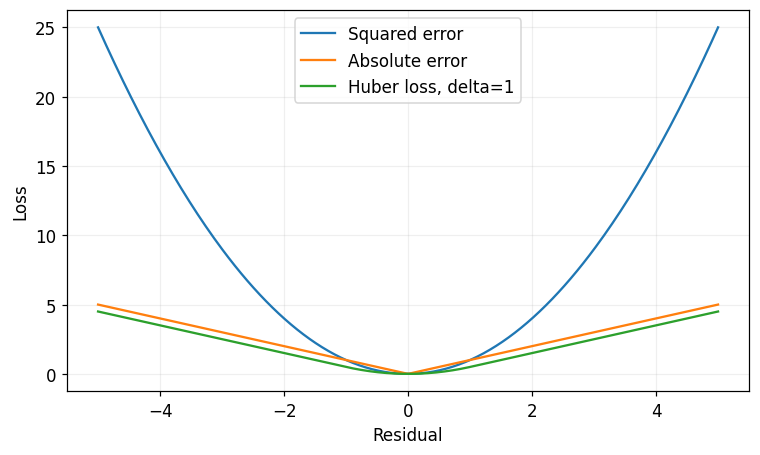

,model,test_RMSE,test_MAE
0,OLS,1.249312,1.049586
1,Huber,0.310303,0.249643


In [21]:
residual=np.linspace(-5,5,300);delta=1.
huber=np.where(np.abs(residual)<=delta,.5*residual**2,delta*(np.abs(residual)-.5*delta))
plt.plot(residual,residual**2,label='Squared error');plt.plot(residual,np.abs(residual),label='Absolute error')
plt.plot(residual,huber,label='Huber loss, delta=1');plt.xlabel('Residual');plt.ylabel('Loss');plt.legend()
savefig('08_robust_losses')
rng=np.random.default_rng(SEED)
X=rng.uniform(-2,2,(100,1));y=2*X[:,0]+1+rng.normal(0,.3,100);y[:8]+=12
X_eval=rng.uniform(-2,2,(300,1));y_eval=2*X_eval[:,0]+1+rng.normal(0,.3,300)
robust=[]
for name,est in [('OLS',LinearRegression()),('Huber',HuberRegressor())]:
    model=make_pipeline(StandardScaler(),est).fit(X,y);pred=model.predict(X_eval)
    robust.append({'model':name,'test_RMSE':root_mean_squared_error(y_eval,pred),'test_MAE':mean_absolute_error(y_eval,pred)})
pd.DataFrame(robust)

In [22]:
# y=0 時百分比誤差本來未定義；sklearn 以極小分母得到巨大有限值。
y_small=np.array([0.,.01,10.]);pred_small=np.array([1.,1.,11.])
print('MAE:',mean_absolute_error(y_small,pred_small))
print('MAPE ratio (not percent):',mean_absolute_percentage_error(y_small,pred_small))
print('Contains zero target:',bool(np.any(y_small==0)))
report('research_extensions',{'leakage_mean':leak_table.mean().to_dict(),'group_validation':group_results,
                              'mismatch':mismatch,'robust_models':robust,
                              'stream_last5_mean_RMSE':stream_table.tail().mean().to_dict()})

MAE: 0.9966666666666667
MAPE ratio (not percent): 1501199875790198.2
Contains zero target: True


## 延伸任務與參考答案

1. online learning 是否自動處理任何漂移？**否，更新速度、模型容量、標籤可得性、災難性遺忘與污染都會影響。**
2. 將隨機標籤實驗的特徵數從 2,000 改成 20，預期洩漏造成的樂觀幅度如何改變？**可搜尋的偶然相關變少，通常幅度較小，但仍須實測。**
3. 房價誤差的 bootstrap CI 能證明 A 模型顯著優於 B 嗎？**不能；需設計配對比較及明確假設，並考慮群組／時間相依與選模過程。**
4. MAPE 遇到 0 應直接加小常數嗎？**不能默默改分母；應依業務定義選指標或明示處理規則，並檢查對結論的影響。**

**報告格式：** 資料生成／來源 → 切分單位與時間 → fit 範圍 → 評估指標 → 重複實驗 → 不確定性 → 可支持與不可支持的結論。